# Anomaly Detection and Isolation Forest

            ## 1. Learning objectives

            - Define anomaly scores and thresholds
- Implement a z-score detector
- Evaluate Isolation Forest under rare positives

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Identify unusual observations when examples of every abnormal pattern are scarce or unavailable.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            Z-scores flag extreme coordinates; Isolation Forest asks how few random splits are needed to isolate a point.

## 6. Mathematical foundation

            $$z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}.$$

            **Every symbol:**

            - $x_{ij}$ is observation i's value for feature j.
- $\mu_j$ is the feature mean.
- $\sigma_j$ is its standard deviation.
- $z_{ij}$ is standardized distance from the mean.

            **Why the equation is needed:** It makes deviations comparable across features with different units.

            **Small numerical example:** If x=16, mean=10, and standard deviation=2, z=(16-10)/2=3.

            **Connection to Python:** (X - X.mean(0)) / X.std(0) computes all z-scores.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def zscore_anomalies(features, threshold=3.0):
    mean = features.mean(axis=0)
    std = features.std(axis=0) + 1e-12
    z_scores = np.abs((features - mean) / std)
    return (z_scores.max(axis=1) > threshold).astype(int), z_scores

example = np.array([[0.], [.1], [-.1], [8.]])
flags, scores = zscore_anomalies(example, threshold=1.5)
print("Example z-scores:", scores.ravel().round(2), "flags:", flags)

Example z-scores: [0.58 0.55 0.61 1.73] flags: [0 0 0 1]


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Isolation Forest precision=0.850, recall=0.850, F1=0.850


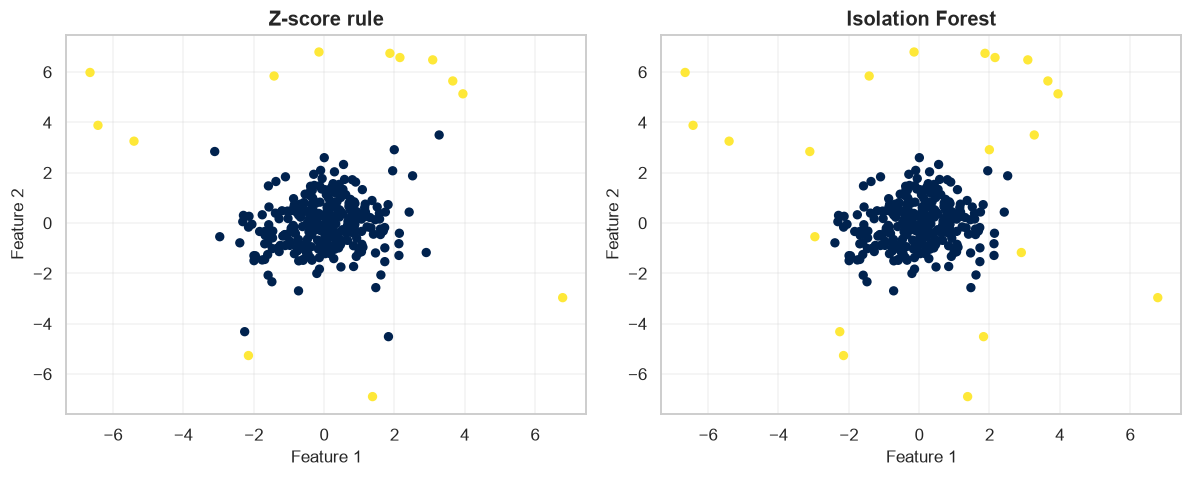

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support

normal = rng.normal(0, 1, size=(280, 2))
outliers = rng.uniform(-7, 7, size=(20, 2))
X = np.vstack([normal, outliers])
y = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(outliers), dtype=int)]
z_flags, z_values = zscore_anomalies(X, threshold=3.0)
model = IsolationForest(contamination=len(outliers) / len(X), random_state=RANDOM_SEED).fit(X)
forest_flags = (model.predict(X) == -1).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(y, forest_flags, average="binary", zero_division=0)
print(f"Isolation Forest precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}")

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, flags, title in zip(axes, [z_flags, forest_flags], ["Z-score rule", "Isolation Forest"]):
    axis.scatter(X[:, 0], X[:, 1], c=flags, cmap="cividis", s=26)
    axis.set(title=title, xlabel="Feature 1", ylabel="Feature 2")
figure.tight_layout()
plt.show()

**How to interpret the result:** Isolation Forest captures jointly unusual points that may not exceed one coordinate's z-score threshold.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Contamination controls the expected anomaly fraction and therefore changes precision and recall.

,contamination,precision,recall,F1
0,0.020,1.00,0.30,0.462
1,0.050,1.00,0.75,0.857
2,0.067,0.81,0.85,0.829
3,0.100,0.60,0.90,0.720
4,0.150,0.40,0.90,0.554


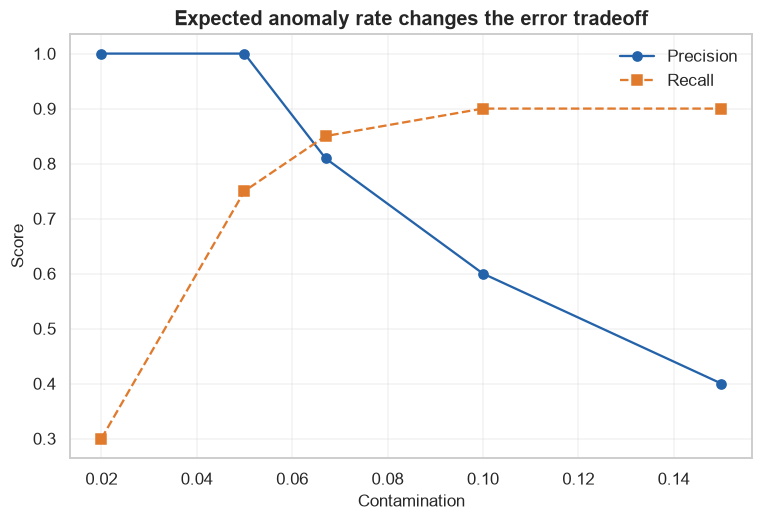

In [4]:
rows = []
for contamination in [.02, .05, .067, .10, .15]:
    candidate = IsolationForest(contamination=contamination, random_state=RANDOM_SEED).fit(X)
    flags = (candidate.predict(X) == -1).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y, flags, average="binary", zero_division=0)
    rows.append({"contamination": contamination, "precision": precision, "recall": recall, "F1": f1})
results = pd.DataFrame(rows)
display(results.round(3))
figure, axis = plt.subplots()
axis.plot(results["contamination"], results["precision"], marker="o", label="Precision", color=COURSE_COLORS["blue"])
axis.plot(results["contamination"], results["recall"], marker="s", linestyle="--", label="Recall", color=COURSE_COLORS["orange"])
axis.set(title="Expected anomaly rate changes the error tradeoff", xlabel="Contamination", ylabel="Score")
axis.legend()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn outlier detection guide](https://scikit-learn.org/stable/modules/outlier_detection.html)